In [49]:
# Changing the directory into notebooks paths
%cd /Users/pangwenjing/Desktop/capstone/capstone/lbp-face-recognition-master  

/Users/pangwenjing/Desktop/capstone/capstone/lbp-face-recognition-master


In [50]:
!pip install import-ipynb

In [30]:
import import_ipynb
from face import load_face_dataset

from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import math
import imutils
import time
import cv2
import os

**Note** : If you save the model, model file will take about `~1.2GB` of your memory. So be careful if you want to save it.

In [57]:
def cross_validation(input_data , cv = 5 , test_size = 0.20 , output = True , save_model=False):
  print("entered")
  

  # initialize the f1-scores list
  f1_scores = []
  # grab some random numbers between 0 and 100
  random_states = np.random.randint(low = 0, high = 100 , size = cv , dtype = int)

  # extract faces and label from dataset
  %run ./face.ipynb
  print("loading dataset........")
  (faces , labels) = load_face_dataset(input_data , minSamples=15)
  print("dataset loaded")

  # encode the labels
  le = LabelEncoder()
  labels = le.fit_transform(labels)
  print("finish labels")

  # do the training process based on the number of 
  # random_states
  for random_state in random_states:
    # split the data into training and test set
    X_train , X_test , y_train , y_test = train_test_split(faces , labels , test_size = test_size,
                                                          stratify = labels , random_state = random_state)
    
    # define and train the LBP model
    print("recognized calling")
    recognizer = cv2.face.LBPHFaceRecognizer_create(
        radius = 1, neighbors = 4, grid_x = 5 , grid_y  = 5)
    print("Checking training data...")
    for i in range(len(X_train)):
        if X_train[i] is None:
            print(f"Image at index {i} is None")
        elif not isinstance(X_train[i], np.ndarray):
            print(f"Image at index {i} is not a numpy array")
        elif len(X_train[i].shape) != 2:
            print(f"Image at index {i} is not grayscale or single-channel")
        elif not isinstance(y_train[i], int):
            y_train[i] = y_train[i].astype(np.int32)
            continue
            print(f"Label at index {i} is not an integer")

    print("Training data checks complete. Starting training...")

    print("recognizer called, start training")
    recognizer.train(X_train , y_train)
    print("finish training")

    # initialize our predictions and confidence lists
    predictions = []
    confidence = []
    print("start predicting")

    # loop over the test data
    for i in range(0 , len(X_test)):
      # classify the face and update the predictions
      # and confidence scores
      (prediction , conf) = recognizer.predict(X_test[i])
      predictions.append(prediction)
      confidence.append(confidence)

    # collect and append the calculated f1-score based on this
    # random state
    f1_scores.append(f1_score(y_test,predictions,average="macro"))

  # convert the f1-scores list into Numpy array
  f1_scores = np.array(f1_scores , dtype="float32")

  if output:
    # generate a sample of testing data
    idxs = np.random.choice(range(0 , len(X_test)) , size = 10 , replace = False)

    for i in idxs:
      # grab the actual and predicted name
      predName = le.inverse_transform([predictions[i]])[0]
      actualName = le.classes_[y_test[i]]

      # grab the face image, convert back it from 1 channel
      # into 3 channels and then resize it
      face = np.dstack([X_test[i]] * 3)
      face = imutils.resize(face , width = 250)

      # draw the actual and predicted name on the image
      cv2.putText(face , "actual : {}".format(actualName) , (5 , 25),
                  cv2.FONT_HERSHEY_SIMPLEX , 0.8 , (0 , 0 , 255) , 2)
      cv2.putText(face , "prediction : {}".format(predName) , (5 , 60),
                  cv2.FONT_HERSHEY_SIMPLEX , 0.8 , (0 , 255 , 0) , 2)

      # display the result image and the save it into
      # the desired directory 
      plt.imshow(face , cmap="gray")
      plt.savefig("output/lbp-faces/face-{}.png".format(i))
    # save the model 

  if save_model:
    # save the model 
    recognizer.save("face-recognizer-model.yml")
  return f1_scores

In [58]:
f1_scores = cross_validation("/Users/pangwenjing/Desktop/capstone/capstone/LBP_Baseline/Computer-Vision-Project/datasets/FER2013" , cv=5 , save_model=True)


entered
/Users/pangwenjing/opt/anaconda3/envs/newenv/bin/python
Loading images...


Processing images: 100%|██████████| 34490/34490 [00:17<00:00, 1961.71it/s]


Converting to arrays...
Completed. Number of faces: 71
{'angry', 'surprise', 'fear', 'disgust', 'happy', 'sad', 'neutral'}
Note: you may need to restart the kernel to use updated packages.
71
71
neutral     12
angry       12
surprise    11
fear        10
disgust     10
happy        9
sad          7
dtype: int64
              precision    recall  f1-score   support

       angry       0.50      0.67      0.57         3
     disgust       0.00      0.00      0.00         1
        fear       0.00      0.00      0.00         2
       happy       0.50      0.33      0.40         3
     neutral       0.00      0.00      0.00         1
         sad       0.00      0.00      0.00         3
    surprise       0.00      0.00      0.00         2

    accuracy                           0.20        15
   macro avg       0.14      0.14      0.14        15
weighted avg       0.20      0.20      0.19        15

loading dataset........
Loading images...


/Users/pangwenjing/opt/anaconda3/envs/newenv/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/pangwenjing/opt/anaconda3/envs/newenv/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/pangwenjing/opt/anaconda3/envs/newenv/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

Converting to arrays...
Completed. Number of faces: 71
dataset loaded
finish labels
recognized calling
Checking training data...
Training data checks complete. Starting training...
recognizer called, start training


error: OpenCV(4.8.1) :-1: error: (-5:Bad argument) in function 'train'
> Overload resolution failed:
>  - Can't parse 'src'. Sequence item with index 0 has a wrong type
>  - Can't parse 'src'. Sequence item with index 0 has a wrong type


In [48]:
# grab the mean of f1-scores
mu = np.mean(f1_scores)
# grab the standard deviation of f1-scores
sigma = np.std(f1_scores)

print("The mean of f1-scores is : " , mu)
print("The standard deviation of f1-scores is : " , sigma)

The mean of f1-scores is :  0.2812124
The standard deviation of f1-scores is :  0.01749127


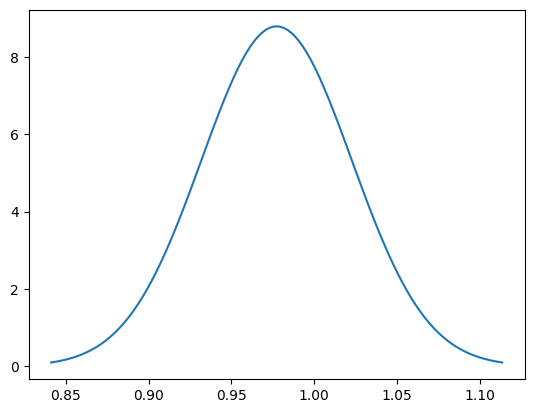

In [7]:
# calculate and divide the normal dist. range into 100 points
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
# plot the normal dist. based on the probability distribution function 
# values 
plt.plot(x, stats.norm.pdf(x, mu, sigma))
# save the plot in the desired directory
plt.savefig("output/model-performance/f-scores-dist.png")
plt.show()

In [59]:
image_path = '/Users/pangwenjing/Desktop/capstone/capstone/LBP_Baseline/Computer-Vision-Project/datasets/FER2013/test/happy/PrivateTest_2028370.jpg'

# Read the image
image = cv2.imread(image_path)

# Convert to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Save the grayscale image
cv2.imwrite('gray_image.jpg', gray_image)

True